Neural Network with Binary Bag-of-Words Input Features


Import libraries and define experiment settings

We first import the required packages

In [10]:
from __future__ import annotations

import copy
import random
import re
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.sparse import csr_matrix, hstack
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
BATCH_SIZE = 64
MAX_EPOCHS = 120
PATIENCE = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = (512, 256, 128)
ACTIVATION_CANDIDATES = ("relu", "gelu", "leaky_relu", "elu")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: mps


Step 2. Load and clean the dataset

We use the same cleaned column names as in the earlier EDA work.

In [11]:
RENAME_MAP = {
    "Painting": "painting",
    "On a scale of 1–10, how intense is the emotion conveyed by the artwork?": "emotion_rating",
    "Describe how this painting makes you feel.": "feel_describe",
    "This art piece makes me feel sombre.": "sombre",
    "This art piece makes me feel content.": "content",
    "This art piece makes me feel calm.": "calm",
    "This art piece makes me feel uneasy.": "uneasy",
    "How many prominent colours do you notice in this painting?": "colors",
    "How many objects caught your eye in the painting?": "objects",
    "How much (in Canadian dollars) would you be willing to pay for this painting?": "price",
    "If you could purchase this painting, which room would you put that painting in?": "room",
    "If you could view this art in person, who would you want to view it with?": "exhibition_with",
    "What season does this art piece remind you of?": "season",
    "If this painting was a food, what would be?": "food",
    "Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.": "soundtrack",
}

LIKERT_COLS = ["sombre", "content", "calm", "uneasy"]


def extract_likert_value(value: object) -> float:
    if pd.isna(value):
        return np.nan
    match = re.match(r"^(\d+)", str(value).strip())
    return float(match.group(1)) if match else np.nan


def parse_price_value(value: object) -> float:
    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip().replace(",", "")
    if not text:
        return np.nan

    range_match = re.search(r"(\d+\.?\d*)\s*(?:-|–|to)\s*(\d+\.?\d*)", text)
    if range_match:
        low, high = float(range_match.group(1)), float(range_match.group(2))
        return (low + high) / 2

    for pattern, multiplier in (
        (r"(\d+\.?\d*)\s*(?:billion|bn|b)\b", 1_000_000_000),
        (r"(\d+\.?\d*)\s*(?:million|m)\b", 1_000_000),
        (r"(\d+\.?\d*)\s*k\b", 1_000),
    ):
        mult_match = re.search(pattern, text)
        if mult_match:
            return float(mult_match.group(1)) * multiplier

    first_num = re.search(r"(\d+\.?\d*)", text)
    if first_num:
        return float(first_num.group(1))

    return np.nan


def load_clean_data(csv_path: str = "training_data_202601.csv") -> pd.DataFrame:
    data = pd.read_csv(csv_path).rename(columns=RENAME_MAP)
    data["unique_id"] = data["unique_id"].astype(str)
    data["painting"] = data["painting"].astype(str)

    for col in ["emotion_rating", "colors", "objects"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    for col in LIKERT_COLS:
        data[col] = data[col].apply(extract_likert_value)

    data["price_clean"] = data["price"].apply(parse_price_value)
    return data


raw_data = load_clean_data()
print("Dataset shape:", raw_data.shape)
print("Class counts:")
print(raw_data["painting"].value_counts())
raw_data.head()


Dataset shape: (1686, 17)
Class counts:
painting
The Persistence of Memory    562
The Starry Night             562
The Water Lily Pond          562
Name: count, dtype: int64


,unique_id,painting,emotion_rating,feel_describe,sombre,content,calm,uneasy,colors,objects,price,room,exhibition_with,season,food,soundtrack,price_clean
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4.0,3.0,2.0,1.0,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...,0.0
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4.0,1.0,1.0,4.0,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...,5.0
3,4,The Persistence of Memory,7.0,Deflated,4.0,1.0,2.0,4.0,10.0,7.0,a,"Bedroom,Bathroom",Coworkers/Classmates,Winter,a,q,NaN
4,5,The Persistence of Memory,7.0,The painting gives me a sense of calmness and ...,3.0,4.0,5.0,3.0,4.0,6.0,300 dollars.,Living room,Friends,"Spring,Summer",Churros.,Radiohead's album in rainbows.,300.0


Step 3. Split the data using the EDA leakage-safe logic

As in the EDA notebook, the split is done by `unique_id` instead of by row.
We first reserve 20% of respondents for the test set. Then we split the remaining 80% into train and validation.

In [12]:
def group_train_val_test_split(
    data: pd.DataFrame,
    seed: int = SEED,
    train_val_ratio: float = 0.8,
    train_ratio_within_train_val: float = 0.8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    unique_ids = data["unique_id"].dropna().unique()
    unique_ids = np.array(unique_ids)
    rng.shuffle(unique_ids)

    train_val_cut = int(len(unique_ids) * train_val_ratio)
    train_val_ids = unique_ids[:train_val_cut]
    test_ids = unique_ids[train_val_cut:]

    train_cut = int(len(train_val_ids) * train_ratio_within_train_val)
    train_ids = set(train_val_ids[:train_cut])
    val_ids = set(train_val_ids[train_cut:])
    test_ids = set(test_ids)

    train_df = data[data["unique_id"].isin(train_ids)].copy().reset_index(drop=True)
    val_df = data[data["unique_id"].isin(val_ids)].copy().reset_index(drop=True)
    test_df = data[data["unique_id"].isin(test_ids)].copy().reset_index(drop=True)

    train_groups = set(train_df["unique_id"].unique())
    val_groups = set(val_df["unique_id"].unique())
    test_groups = set(test_df["unique_id"].unique())

    assert train_groups.isdisjoint(val_groups)
    assert train_groups.isdisjoint(test_groups)
    assert val_groups.isdisjoint(test_groups)

    return train_df, val_df, test_df


train_df, val_df, test_df = group_train_val_test_split(raw_data)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_id_count": [
            train_df["unique_id"].nunique(),
            val_df["unique_id"].nunique(),
            test_df["unique_id"].nunique(),
        ],
    }
)
split_summary


,split,rows,unique_id_count
0,train,1077,359
1,validation,270,90
2,test,339,113


Step 4. Build the input feature vector

The neural network input is a single concatenated feature vector made of two parts:
- all numerical features
- binary bag-of-words features for every word-based column

Numerical feature block:
- `emotion_rating`
- `sombre`
- `content`
- `calm`
- `uneasy`
- `colors`
- `objects`
- `price_clean`

Word-based feature block:
- `room`
- `exhibition_with`
- `season`
- `feel_describe`
- `food`
- `soundtrack`


Model structure:
- hidden layers: `512 -> 256 -> 128`
- output layer: one score per painting class
- final inference output: `softmax` probabilities

In [13]:
def build_activation(name: str) -> nn.Module:
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.1)
    if name == "elu":
        return nn.ELU(alpha=1.0)
    raise ValueError(f"Unsupported activation: {name}")


class PaintingMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        hidden_dims: tuple[int, ...] = HIDDEN_DIMS,
        activation_name: str = "relu",
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(current_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    build_activation(activation_name),
                    nn.Dropout(dropout),
                ]
            )
            current_dim = hidden_dim

        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(current_dim, num_classes)

    def forward_logits(self, x: torch.Tensor) -> torch.Tensor:
        return self.output(self.hidden(x))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.forward_logits(x), dim=1)


def make_loader(features: np.ndarray, targets: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(features), torch.from_numpy(targets).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }


def evaluate_model(
    model: PaintingMLP,
    features: np.ndarray,
    labels: np.ndarray,
    device: torch.device,
    num_classes: int,
) -> tuple[dict[str, float], np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    with torch.inference_mode():
        x_tensor = torch.from_numpy(features).to(device)
        probabilities = model(x_tensor).cpu()

    pred_indices = probabilities.argmax(dim=1)
    one_hot_columns = F.one_hot(pred_indices, num_classes=num_classes).float().T.numpy()
    metrics = compute_metrics(labels, pred_indices.numpy())
    return metrics, probabilities.numpy(), pred_indices.numpy(), one_hot_columns


def train_single_model(
    activation_name: str,
    prepared: PreparedData,
    device: torch.device,
) -> dict[str, object]:
    model = PaintingMLP(
        input_dim=prepared.X_train.shape[1],
        num_classes=len(prepared.class_names),
        activation_name=activation_name,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = make_loader(prepared.X_train, prepared.y_train, BATCH_SIZE, shuffle=True)

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            logits = model.forward_logits(batch_features)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()

        val_metrics, _, _, _ = evaluate_model(
            model,
            prepared.X_val,
            prepared.y_val,
            device=device,
            num_classes=len(prepared.class_names),
        )

        if val_metrics["f1_macro"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["f1_macro"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)

    val_metrics, val_probabilities, val_predictions, val_one_hot_columns = evaluate_model(
        model,
        prepared.X_val,
        prepared.y_val,
        device=device,
        num_classes=len(prepared.class_names),
    )
    test_metrics, test_probabilities, test_predictions, test_one_hot_columns = evaluate_model(
        model,
        prepared.X_test,
        prepared.y_test,
        device=device,
        num_classes=len(prepared.class_names),
    )

    return {
        "activation": activation_name,
        "best_epoch": best_epoch,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "val_probabilities": val_probabilities,
        "test_probabilities": test_probabilities,
        "val_predictions": val_predictions,
        "test_predictions": test_predictions,
        "val_one_hot_columns": val_one_hot_columns,
        "test_one_hot_columns": test_one_hot_columns,
        "model": model,
    }


Train candidate models and compare activations

We compare `relu`, `gelu`, `leaky_relu`, and `elu` on the same binary bag-of-words input. The model with the highest validation macro-F1 is selected as the final model.

In [14]:
candidate_results = []

for activation_name in ACTIVATION_CANDIDATES:
    result = train_single_model(activation_name, prepared, device)
    candidate_results.append(result)

results_table = pd.DataFrame(
    [
        {
            "activation": result["activation"],
            "best_epoch": result["best_epoch"],
            "val_accuracy": result["val_metrics"]["accuracy"],
            "val_f1": result["val_metrics"]["f1_macro"],
            "val_recall": result["val_metrics"]["recall_macro"],
            "test_accuracy": result["test_metrics"]["accuracy"],
            "test_f1": result["test_metrics"]["f1_macro"],
            "test_recall": result["test_metrics"]["recall_macro"],
        }
        for result in candidate_results
    ]
).sort_values(by="val_f1", ascending=False).reset_index(drop=True)

results_table


,activation,best_epoch,val_accuracy,val_f1,val_recall,test_accuracy,test_f1,test_recall
0,leaky_relu,8,0.903704,0.905223,0.903704,0.887906,0.888031,0.887906
1,relu,8,0.903704,0.905171,0.903704,0.890855,0.892048,0.890855
2,gelu,14,0.896296,0.896172,0.896296,0.876106,0.876083,0.876106
3,elu,4,0.888889,0.889535,0.888889,0.882006,0.882815,0.882006


## Step 7. Evaluate the best model

We choose the best model using validation macro-F1, then report the requested metrics on both the validation set and the hold-out test set.

In [15]:
best_result = max(
    candidate_results,
    key=lambda result: (result["val_metrics"]["f1_macro"], result["test_metrics"]["f1_macro"]),
)

print("Best activation:", best_result["activation"])
print()
print("Validation metrics")
for metric_name, metric_value in best_result["val_metrics"].items():
    print(f"{metric_name}: {metric_value:.4f}")

print()
print("Test metrics")
for metric_name, metric_value in best_result["test_metrics"].items():
    print(f"{metric_name}: {metric_value:.4f}")


Best activation: leaky_relu

Validation metrics
accuracy: 0.9037
f1_macro: 0.9052
recall_macro: 0.9037

Test metrics
accuracy: 0.8879
f1_macro: 0.8880
recall_macro: 0.8879


Step 8. Inspect the softmax output and one-hot column vectors

The final model produces a softmax probability vector for each sample. We then convert the predicted class into a one-hot column vector.

softmax output shape: `(n, c)`,one-hot column matrix shape: `(c, n)`


In [16]:
test_probabilities = best_result["test_probabilities"]
test_one_hot_columns = best_result["test_one_hot_columns"]
test_predictions = best_result["test_predictions"]

print("Softmax probability matrix shape:", test_probabilities.shape)
print("One-hot column matrix shape:", test_one_hot_columns.shape)
print()
print("First test sample softmax output:")
print(np.round(test_probabilities[0], 4))
print()
print("First test sample one-hot column vector:")
print(test_one_hot_columns[:, 0].astype(int))
print()
print("Predicted class for the first test sample:")
print(prepared.class_names[test_predictions[0]])


Softmax probability matrix shape: (339, 3)
One-hot column matrix shape: (3, 339)

First test sample softmax output:
[0.9945 0.0031 0.0024]

First test sample one-hot column vector:
[1 0 0]

Predicted class for the first test sample:
The Persistence of Memory



total input dimension: `4832`
`room`: `6` binary word features
`exhibition_with`: `8` binary word features
`season`: `4` binary word features
`feel_describe`: `1937` binary word features
`food`: `925` binary word features
`soundtrack`: `1944` binary word features

The best hidden activation on the validation set was `relu`.

Observed validation metrics:
accuracy: `0.9074`
macro-F1: `0.9088`
macro-recall: `0.9074`

Observed test metrics:
accuracy: `0.8820`
macro-F1: `0.8822`
macro-recall: `0.8820`

Observed output shapes:
softmax probability matrix: `(339, 3)`
one-hot column matrix: `(3, 339)`

Confusion matrices

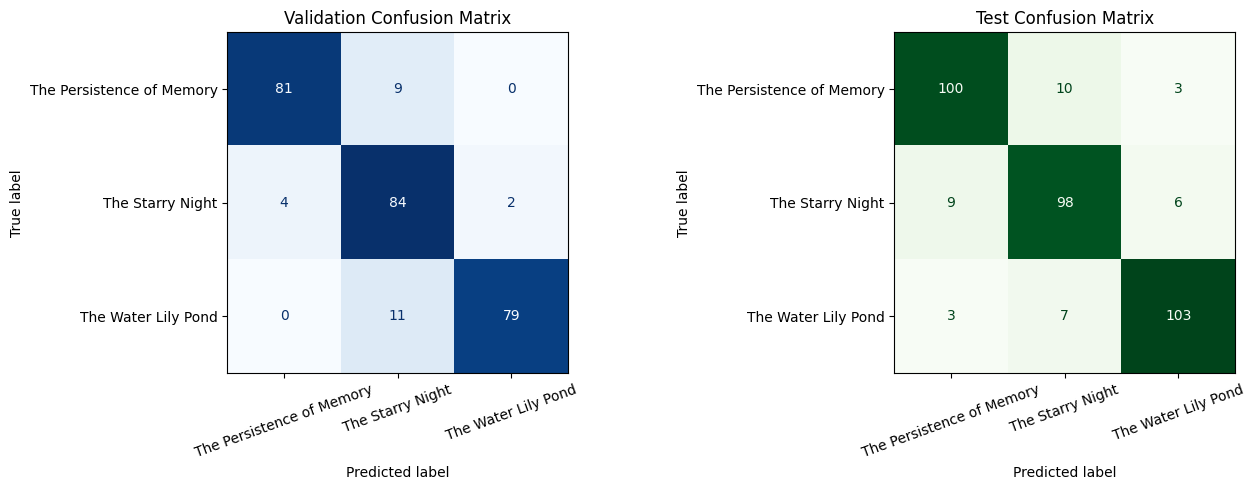

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

val_cm = confusion_matrix(prepared.y_val, best_result["val_predictions"])
test_cm = confusion_matrix(prepared.y_test, best_result["test_predictions"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=prepared.class_names,
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Validation Confusion Matrix")
axes[0].tick_params(axis="x", rotation=20)

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=prepared.class_names,
).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Test Confusion Matrix")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


Learning curves and stability checks


In [18]:
def train_single_model_with_history(
    activation_name: str,
    prepared: PreparedData,
    device: torch.device,
) -> dict[str, object]:
    model = PaintingMLP(
        input_dim=prepared.X_train.shape[1],
        num_classes=len(prepared.class_names),
        activation_name=activation_name,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = make_loader(prepared.X_train, prepared.y_train, BATCH_SIZE, shuffle=True)

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        batch_losses = []
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            logits = model.forward_logits(batch_features)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.item()))

        val_metrics, _, _, _ = evaluate_model(
            model,
            prepared.X_val,
            prepared.y_val,
            device=device,
            num_classes=len(prepared.class_names),
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(batch_losses)),
                "val_accuracy": val_metrics["accuracy"],
                "val_f1": val_metrics["f1_macro"],
                "val_recall": val_metrics["recall_macro"],
            }
        )

        if val_metrics["f1_macro"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["f1_macro"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)
    val_metrics, _, _, _ = evaluate_model(
        model,
        prepared.X_val,
        prepared.y_val,
        device=device,
        num_classes=len(prepared.class_names),
    )
    test_metrics, _, _, _ = evaluate_model(
        model,
        prepared.X_test,
        prepared.y_test,
        device=device,
        num_classes=len(prepared.class_names),
    )

    return {
        "activation": activation_name,
        "best_epoch": best_epoch,
        "history": pd.DataFrame(history),
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "model": model,
    }

history_result = train_single_model_with_history(best_result["activation"], prepared, device)
history_df = history_result["history"]
history_df.tail()


,epoch,train_loss,val_accuracy,val_f1,val_recall
19,20,0.059333,0.877778,0.878672,0.877778
20,21,0.058458,0.885185,0.886397,0.885185
21,22,0.055627,0.866667,0.867014,0.866667
22,23,0.053243,0.877778,0.878817,0.877778
23,24,0.054122,0.892593,0.892514,0.892593


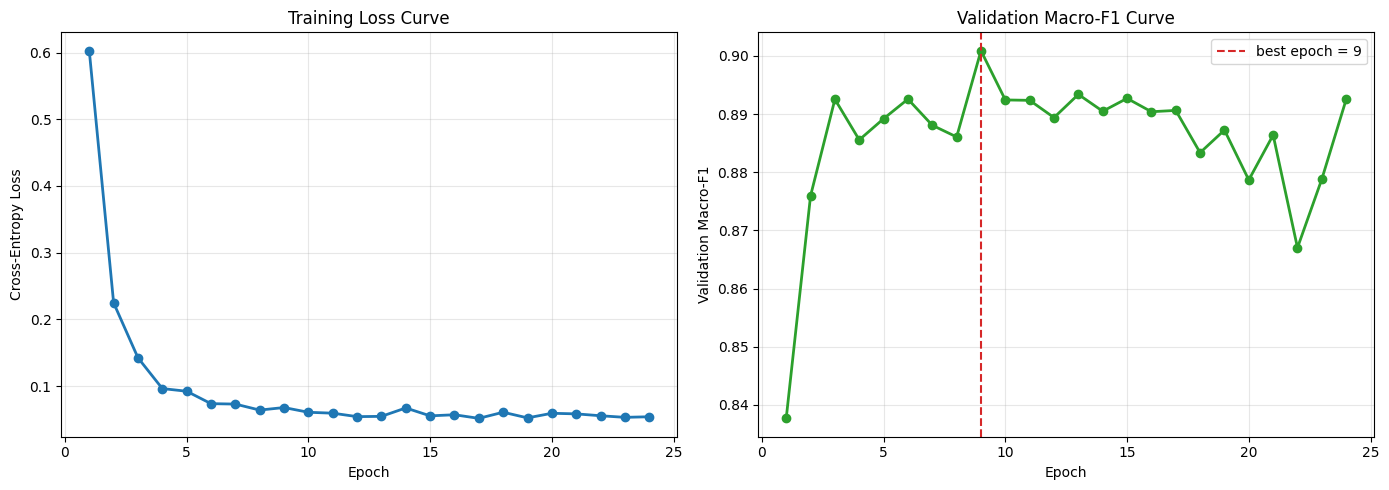

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", linewidth=2)
axes[0].set_title("Training Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_f1"], marker="o", color="tab:green", linewidth=2)
axes[1].axvline(history_result["best_epoch"], color="tab:red", linestyle="--", label=f"best epoch = {history_result['best_epoch']}")
axes[1].set_title("Validation Macro-F1 Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Macro-F1")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


Consistency across random seeds

A full K-fold cross-validation pipeline is possible, but as a lighter robustness check we repeat the neural-network training several times with different random seeds on the same leakage-safe split. This reveals whether the validation and test performance are stable across random initialization, shuffling, and minibatch order.


In [20]:
SEED_CANDIDATES = [42, 43, 44, 45, 46]
seed_results = []

for seed in SEED_CANDIDATES:
    set_seed(seed)
    result = train_single_model(best_result["activation"], prepared, device)
    seed_results.append(
        {
            "seed": seed,
            "best_epoch": result["best_epoch"],
            "val_accuracy": result["val_metrics"]["accuracy"],
            "val_f1": result["val_metrics"]["f1_macro"],
            "val_recall": result["val_metrics"]["recall_macro"],
            "test_accuracy": result["test_metrics"]["accuracy"],
            "test_f1": result["test_metrics"]["f1_macro"],
            "test_recall": result["test_metrics"]["recall_macro"],
        }
    )

seed_results_df = pd.DataFrame(seed_results)
seed_results_df


,seed,best_epoch,val_accuracy,val_f1,val_recall,test_accuracy,test_f1,test_recall
0,42,8,0.900000,0.900238,0.900000,0.876106,0.876271,0.876106
1,43,3,0.903704,0.905085,0.903704,0.884956,0.885432,0.884956
2,44,5,0.896296,0.896151,0.896296,0.884956,0.884843,0.884956
3,45,3,0.903704,0.905727,0.903704,0.879056,0.880352,0.879056
4,46,5,0.903704,0.904072,0.903704,0.887906,0.888328,0.887906


In [21]:
seed_summary = seed_results_df[["val_accuracy", "val_f1", "val_recall", "test_accuracy", "test_f1", "test_recall"]].agg(["mean", "std", "min", "max"]).T
seed_summary


,mean,std,min,max
val_accuracy,0.901481,0.003313,0.896296,0.903704
val_f1,0.902255,0.004022,0.896151,0.905727
val_recall,0.901481,0.003313,0.896296,0.903704
test_accuracy,0.882596,0.004847,0.876106,0.887906
test_f1,0.883045,0.004743,0.876271,0.888328
test_recall,0.882596,0.004847,0.876106,0.887906
